# Load data

In [1]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 26.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [rasterio]4/5 [rasterio]

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import geopandas as gpd
import pandas as pd

In [3]:
subbasin_gdf = gpd.read_file('../data/raw/hydrography/gsl_catchment.shp')
gage_df = pd.read_csv('../data/raw/hydrography/gsl_nwm_gage.csv')
well_gdf = gpd.read_file('../data/raw/hydrography/well_shp.shp')
stream_gdf = gpd.read_file('../data/raw/hydrography/gslb_stream.shp')
lake_gdf = gpd.read_file('../data/raw/hydrography/lake.shp')

# find downstream gage

In [4]:
from geopandas import GeoDataFrame
from shapely.geometry import Point

# Convert gage dataframe to GeoDataFrame (to match with subbasin_gdf)
# Create point geometries from longitude/latitude coordinates
gage_gdf = gpd.GeoDataFrame(
    gage_df,
    geometry=gpd.points_from_xy(gage_df['longitude'], gage_df['latitude']),
    crs=subbasin_gdf.crs
)

# Spatial join to find which subbasin each gage falls within
# Only keep gages that are within a subbasin (inner join)
matched_gages = gpd.sjoin(
    gage_gdf[['id', 'name', 'geometry']],
    subbasin_gdf[['linkno', 'geometry']],
    how='inner',
    predicate='within'
).rename(columns={'linkno': 'catchment_id'})

# Keep only relevant columns
matched_gages = matched_gages[['id', 'name', 'geometry', 'catchment_id']]



In [5]:
# Create a directed graph representing the river network
import networkx as nx
G = nx.DiGraph()

# Add edges to graph based on stream connectivity
# DSLINKNO represents downstream link number
for _, row in stream_gdf.iterrows():
    if pd.notna(row['DSLINKNO']) and row['DSLINKNO'] > 0:
        G.add_edge(int(row['LINKNO']), int(row['DSLINKNO']))

# Create dictionary mapping gage IDs to their catchment IDs
gage_links = dict(zip(matched_gages['id'], matched_gages['catchment_id']))
terminal_ids = []

# Find terminal gages (those that don't flow to any other gage)
for g1_id, g1_link in gage_links.items():
    is_terminal = True
    for g2_id, g2_link in gage_links.items():
        if g1_id != g2_id:
            try:
                # If there's a path from g1 to g2, then g1 is not terminal
                if nx.has_path(G, g1_link, g2_link):
                    is_terminal = False
                    break
            except:
                continue
    if is_terminal:
        terminal_ids.append(g1_id)

In [6]:
# Manual adjustments to terminal gages list based on domain knowledge
gages_to_remove = [10171000, 10167000]
gages_to_add = [10163000, 10153100, 10152000]

In [7]:
# Remove specified gages
terminal_ids = [gage_id for gage_id in terminal_ids if gage_id not in gages_to_remove]

# Add new gages if they exist in matched_gages
for gage_id in gages_to_add:
    if gage_id in matched_gages['id'].values and gage_id not in terminal_ids:
        terminal_ids.append(gage_id)

# Create dataframe of terminal gages
terminal_gages = matched_gages[matched_gages['id'].isin(terminal_ids)].copy()

# Find all upstream catchments for each terminal gage
records = []
for _, gage in terminal_gages.iterrows():
    upstream_ids = set()
    # Check each node in the graph
    for node in G.nodes:
        # If there's a path from node to terminal gage's catchment,
        # then this node is upstream
        if nx.has_path(G, node, gage['catchment_id']):
            upstream_ids.add(node)
    # Include the terminal gage's own catchment
    upstream_ids.add(gage['catchment_id'])

    # Create records for each upstream catchment
    for up_id in upstream_ids:
        records.append({
            'Gage_ID': gage['id'],
            'Gage_Name': gage['name'],
            'Terminal_Catchment_ID': gage['catchment_id'],
            'Upstream_Catchment_ID': up_id
        })

# Create and save the final dataframe
df_upstream = pd.DataFrame(records)
df_upstream.to_csv("../data/processed/terminal_gage_upstream_catchments.csv", index=False)

In [8]:
print(f'Number of unique gages in df_upstream: {df_upstream["Gage_ID"].nunique()}')
print('\nTerminal gage names:')
for _, row in df_upstream[['Gage_ID', 'Gage_Name']].drop_duplicates().iterrows():
    print(f'{row["Gage_ID"]}: {row["Gage_Name"]}')


Number of unique gages in df_upstream: 12

Terminal gage names:
10126000: BEAR RIVER NEAR CORINNE - UT
10141000: WEBER RIVER NEAR PLAIN CITY - UT
10142000: FARMINGTON CR ABV DIV NR FARMINGTON - UTAH
10143500: CENTERVILLE CREEK ABV. DIV NEAR CENTERVILLE - UT
10152000: SPANISH FORK NEAR LAKE SHORE - UTAH
10153100: HOBBLE CREEK AT 1650 WEST AT SPRINGVILLE - UTAH
10163000: PROVO RIVER AT PROVO - UT
10168000: LITTLE COTTONWOOD CREEK @ JORDAN RIVER NR SLC
10168500: BIG COTTONWOOD CR NR SALT LAKE CITY UTAH
10172700: VERNON CREEK NEAR VERNON - UT
10172860: WARM CREEK NEAR GANDY - UT
10172952: DUNN CREEK NEAR PARK VALLEY - UT


# Plot

In [9]:
import matplotlib.pyplot as plt
plt.style.use('default')  # Reset any style settings

In [11]:
!pip install plotly
!pip install plotly-express
!pip install plotly-graph-objects
!pip install plotly-subplots
!pip install plotly
!pip install plotly-express
!pip install plotly-graph-objects

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 34.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 61.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [plotly-express]m [statsmodels]

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement plotly-graph-objects (from versions: none)

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for plotly-graph-objects
ERROR: Could not find a version that satisfies the requirement plotly-subplots (from versions: none)

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run:

In [12]:
# ... existing code ...
import numpy as np
import pandas as pd
import geopandas as gpd
# If you previously had "import plotly as plt", remove it and use explicit aliases instead:
import matplotlib.pyplot as plt
import plotly.express as px         # if you use Plotly Express
import plotly.graph_objects as go    # if you use Graph Objects
from plotly.subplots import make_subplots  # if you need Plotly subplots
# ... existing code ...
import plotly.express as px

=== Creating Enhanced Watershed Visualization ===


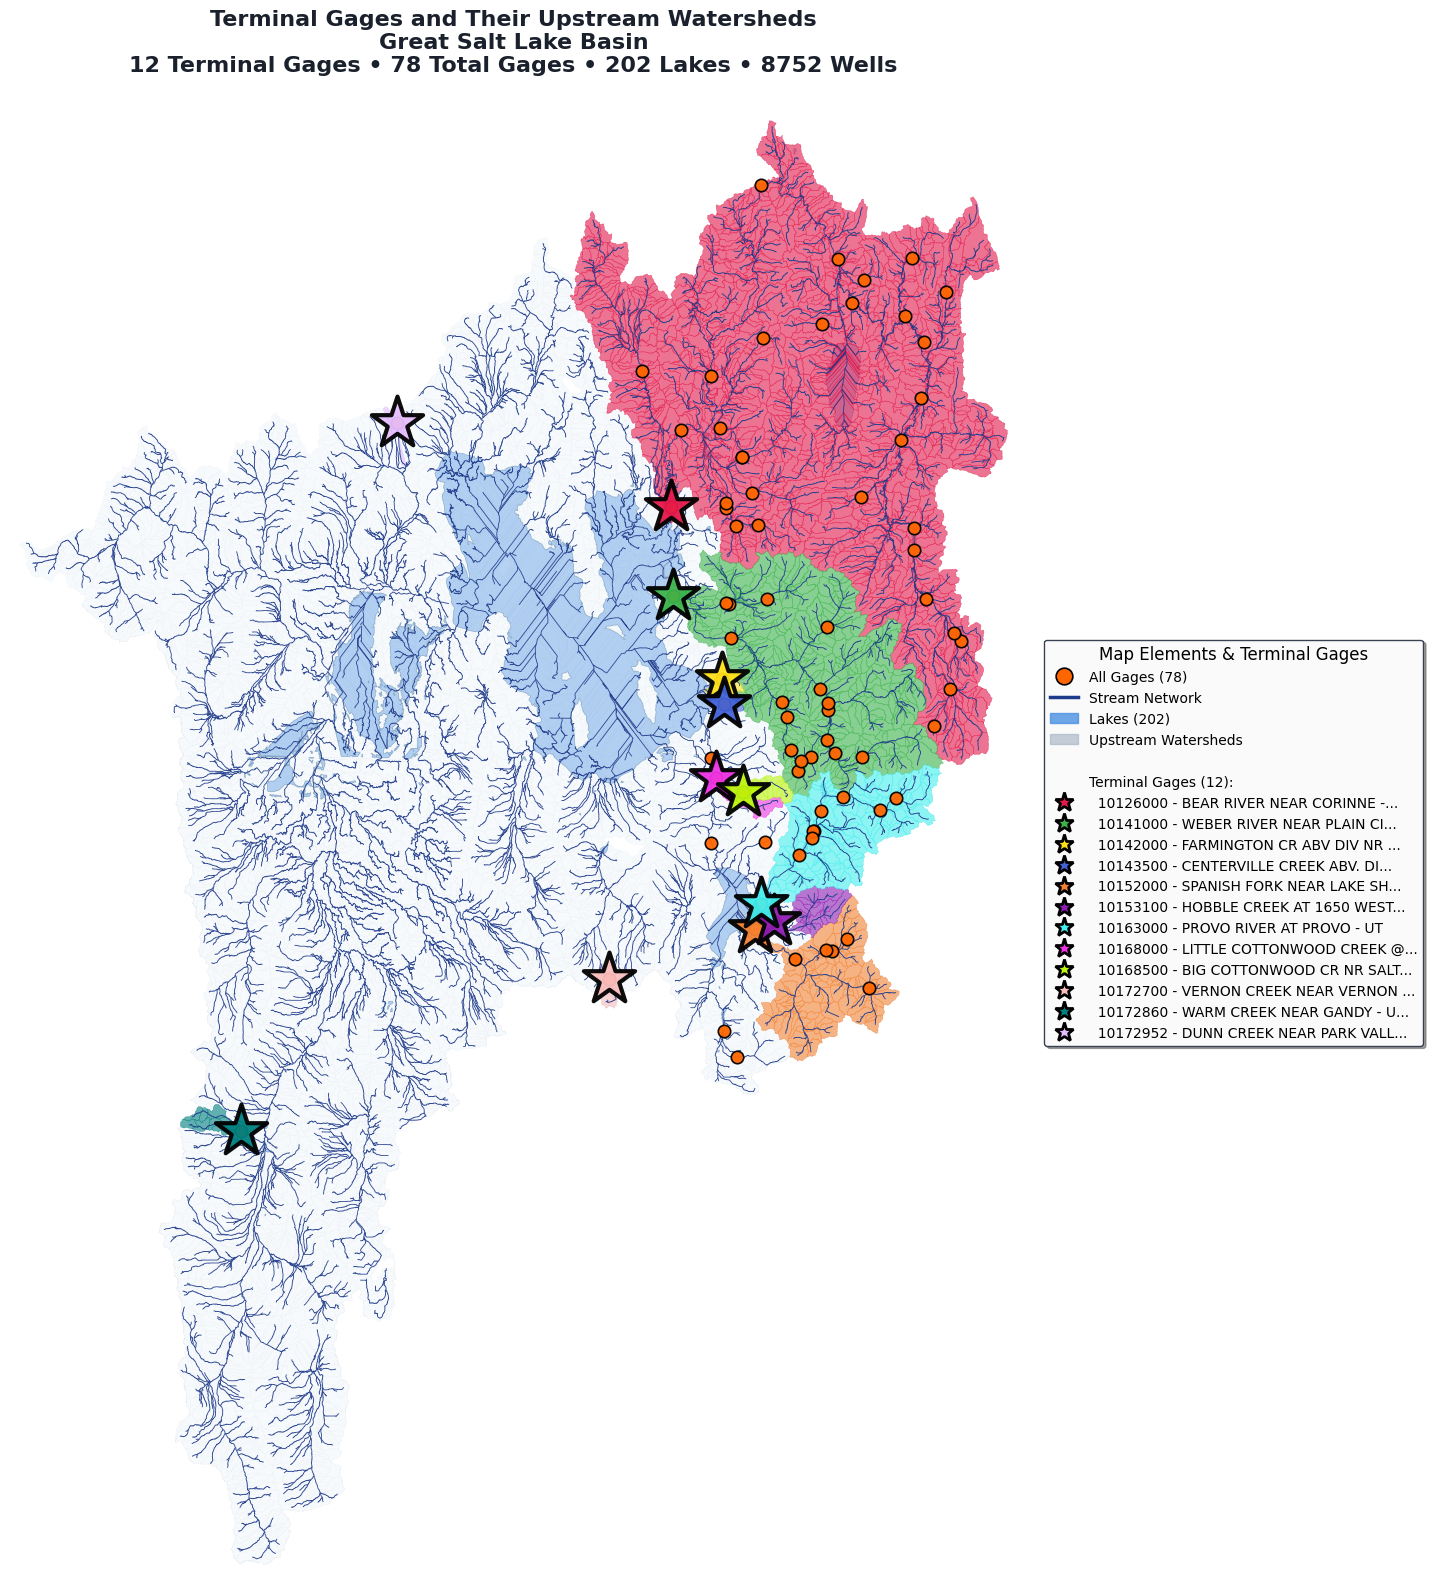

✅ Visualization saved to: reports/figures/enhanced_terminal_gages_watersheds.png
📊 Added 8752 wells to the visualization


In [14]:
def create_enhanced_watershed_visualization():
    """
    Create enhanced watershed visualization with bright colors and large gages
    """
    print("=== Creating Enhanced Watershed Visualization ===")

    # Load data
    terminal_mapping = pd.read_csv('../data/processed/terminal_gage_upstream_catchments.csv')
    subbasin_gdf = gpd.read_file('../data/raw/hydrography/gsl_catchment.shp')
    gage_df = pd.read_csv('../data/raw/hydrography/gsl_nwm_gage.csv')
    well_gdf = gpd.read_file('../data/raw/hydrography/well_shp.shp')
    stream_gdf = gpd.read_file('../data/raw/hydrography/gslb_stream.shp')
    lake_gdf = gpd.read_file('../data/raw/hydrography/lake.shp')
    # Find linkno column
    linkno_col = 'linkno' if 'linkno' in subbasin_gdf.columns else 'LINKNO'

    # Data preprocessing
    if 'Gage_ID' in terminal_mapping.columns:
        terminal_mapping = terminal_mapping.rename(columns={
            'Gage_ID': 'gage_id',
            'Upstream_Catchment_ID': 'upstream_catchment_id'
        })

    terminal_mapping = terminal_mapping.dropna(subset=['upstream_catchment_id'])
    terminal_mapping['gage_id'] = terminal_mapping['gage_id'].astype(int)
    terminal_mapping['upstream_catchment_id'] = terminal_mapping['upstream_catchment_id'].astype(int)

    gage_df['id'] = gage_df['id'].astype(int)
    subbasin_gdf = subbasin_gdf.dropna(subset=[linkno_col])
    subbasin_gdf[linkno_col] = subbasin_gdf[linkno_col].astype(int)

    # Get terminal gages and create catchments dictionary
    terminal_gage_ids = terminal_mapping['gage_id'].unique().tolist()
    terminal_gages = gage_df[gage_df['id'].isin(terminal_gage_ids)].copy()

    terminal_gage_catchments = {}
    available_catchments = set(subbasin_gdf[linkno_col].unique())

    for gage_id in terminal_gage_ids:
        upstream_catchments = terminal_mapping[
            terminal_mapping['gage_id'] == gage_id
        ]['upstream_catchment_id'].tolist()

        valid_catchments = [c for c in upstream_catchments if c in available_catchments]
        if valid_catchments:
            terminal_gage_catchments[gage_id] = set(valid_catchments)

    # Convert to Web Mercator
    subbasin_web = subbasin_gdf.to_crs('EPSG:3857')
    stream_web = stream_gdf.to_crs('EPSG:3857')
    lake_web = lake_gdf.to_crs('EPSG:3857')
    well_web = well_gdf.to_crs('EPSG:3857')  # Convert wells to Web Mercator

    gage_gdf_web = gpd.GeoDataFrame(
        gage_df,
        geometry=gpd.points_from_xy(gage_df['longitude'], gage_df['latitude']),
        crs='EPSG:4326'
    ).to_crs('EPSG:3857')

    terminal_gages_web = gpd.GeoDataFrame(
        terminal_gages,
        geometry=gpd.points_from_xy(terminal_gages['longitude'], terminal_gages['latitude']),
        crs='EPSG:4326'
    ).to_crs('EPSG:3857')

    # New bright professional colors
    bright_colors = [
    '#E6194B',  # bright red
    '#3CB44B',  # bright green
    '#FFE119',  # bright yellow
    '#4363D8',  # royal blue
    '#F58231',  # orange
    '#911EB4',  # violet
    '#46F0F0',  # lake blue
    '#F032E6',  # magenta
    '#BCF60C',  # yellow-green
    '#FABEBE',  # light pink
    '#008080',  # turquoise
    '#E6BEFF',  # light purple
    '#9A6324',  # brown
    '#FFFAC8',  # ivory yellow
    '#800000',  # dark red
    '#AAFFC3',  # mint green
    '#808000',  # olive green
    '#FFD8B1',  # apricot orange
    '#000075',  # navy blue
    '#808080'   # medium gray
]

    terminal_gage_colors = dict(zip(terminal_gage_ids, bright_colors[:len(terminal_gage_ids)]))

    # Create plot
    fig, ax = plt.subplots(1, 1, figsize=(22, 16))

    # 1. Plot subbasins background
    subbasin_web.plot(ax=ax, color='#F7FAFC', edgecolor='#E2E8F0', linewidth=0.1, alpha=0.9, zorder=1)

    # 2. Add lakes (darker blue, more visible)
    lake_web.plot(ax=ax, color='#4A90E2', edgecolor='#2E5F8A',  # Changed to darker blue
                  linewidth=0.5, alpha=0.4, zorder=1.5)  # Increased alpha for better visibility

    # 3. Highlight watersheds
    for gage_id in terminal_gage_ids:
        if gage_id in terminal_gage_catchments:
            upstream_catchments = list(terminal_gage_catchments[gage_id])
            upstream_basins = subbasin_web[subbasin_web[linkno_col].isin(upstream_catchments)]

            if not upstream_basins.empty:
                upstream_basins.plot(
                    ax=ax,
                    color=terminal_gage_colors[gage_id],
                    alpha=0.6,
                    edgecolor=terminal_gage_colors[gage_id],
                    linewidth=0.3,
                    zorder=2
                )

    # 4. Add streams (dark blue)
    stream_web.plot(ax=ax, color='#1E3A8A', linewidth=0.6, alpha=0.9, zorder=3)


    # 6. Plot all gages (bright and large)
    gage_gdf_web.plot(ax=ax, color='#FF6600', markersize=80, alpha=0.95,  # Much larger and brighter
                      edgecolor='#000000', linewidth=1.2, zorder=4)

    # 7. Plot terminal gages (bright stars)
    terminal_gage_info = []
    for _, row in terminal_gages_web.iterrows():
        gage_id = int(row['id'])

        if gage_id in terminal_gage_catchments:
            x_coord = row.geometry.x
            y_coord = row.geometry.y

            ax.scatter([x_coord], [y_coord],
                       c=[terminal_gage_colors[gage_id]],
                       marker='*', s=1500,  # Larger stars
                       edgecolors='#000000', linewidths=3.0,
                       zorder=5, alpha=0.95)

            # Collect info for legend
            gage_name = row.get('name', f'Gage {gage_id}')
            river = row.get('River', 'Unknown River')
            terminal_gage_info.append({
                'id': gage_id,
                'name': gage_name,
                'river': river,
                'color': terminal_gage_colors[gage_id]
            })

    # 8. Add base map
    try:
        import contextily as ctx
        ctx.add_basemap(ax, crs=subbasin_web.crs,
                        source=ctx.providers.CartoDB.Positron,
                        zorder=0, alpha=0.3)
    except:
        pass

    # 9. Create legend
    from matplotlib.patches import Patch

    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w',
                  markerfacecolor='#FF6600', markersize=12,
                  markeredgecolor='#000000', markeredgewidth=1.2,
                  label=f'All Gages ({len(gage_df)})'),
        plt.Line2D([0], [0], color='#1E3A8A', linewidth=2.5,
                  label='Stream Network'),
        Patch(color='#4A90E2', alpha=0.8, label=f'Lakes ({len(lake_gdf)})'),  # Updated lake color in legend
        Patch(color='#A0AEC0', alpha=0.6, label='Upstream Watersheds'),
        plt.Line2D([0], [0], color='none', label=''),  # Spacer
        plt.Line2D([0], [0], color='none', label=f'Terminal Gages ({len(terminal_gage_info)}):')
    ]

    # Add terminal gages to legend
    terminal_gage_info.sort(key=lambda x: x['id'])
    for info in terminal_gage_info:
        display_name = info['name'][:25] + "..." if len(info['name']) > 25 else info['name']
        legend_elements.append(
            plt.Line2D([0], [0], marker='*', color='w',
                      markerfacecolor=info['color'], markersize=14,
                      markeredgecolor='#000000', markeredgewidth=2.0,
                      label=f'  {info["id"]} - {display_name}')
        )

    # Set legend
    ax.legend(handles=legend_elements,
             loc='center left', bbox_to_anchor=(1.02, 0.5),
             fontsize=10, title='Map Elements & Terminal Gages',
             title_fontsize=12, frameon=True, fancybox=True,
             shadow=True, framealpha=0.95, facecolor='white',
             edgecolor='#2D3748')

    # 10. Title
    ax.set_title(f"Terminal Gages and Their Upstream Watersheds\n"
                f"Great Salt Lake Basin\n"
                f"{len(terminal_gage_ids)} Terminal Gages • {len(gage_df)} Total Gages • {len(lake_gdf)} Lakes • {len(well_gdf)} Wells",
                fontsize=16, pad=25, fontweight='bold', color='#1A202C')

    # 11. Format and save
    ax.set_aspect('equal')
    ax.axis('off')
    ax.margins(0.01)
    plt.tight_layout()

    import os
    plt.savefig("../reports/figures/enhanced_terminal_gages_watersheds.png",
                dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.show()

    print(f"✅ Visualization saved to: reports/figures/enhanced_terminal_gages_watersheds.png")
    print(f"📊 Added {len(well_gdf)} wells to the visualization")

# Run visualization
create_enhanced_watershed_visualization()


=== Creating Enhanced Watershed Visualization ===
  Streams total: 6717, order >= 4: 1765
  Wells total: 8752, within basin: 8740


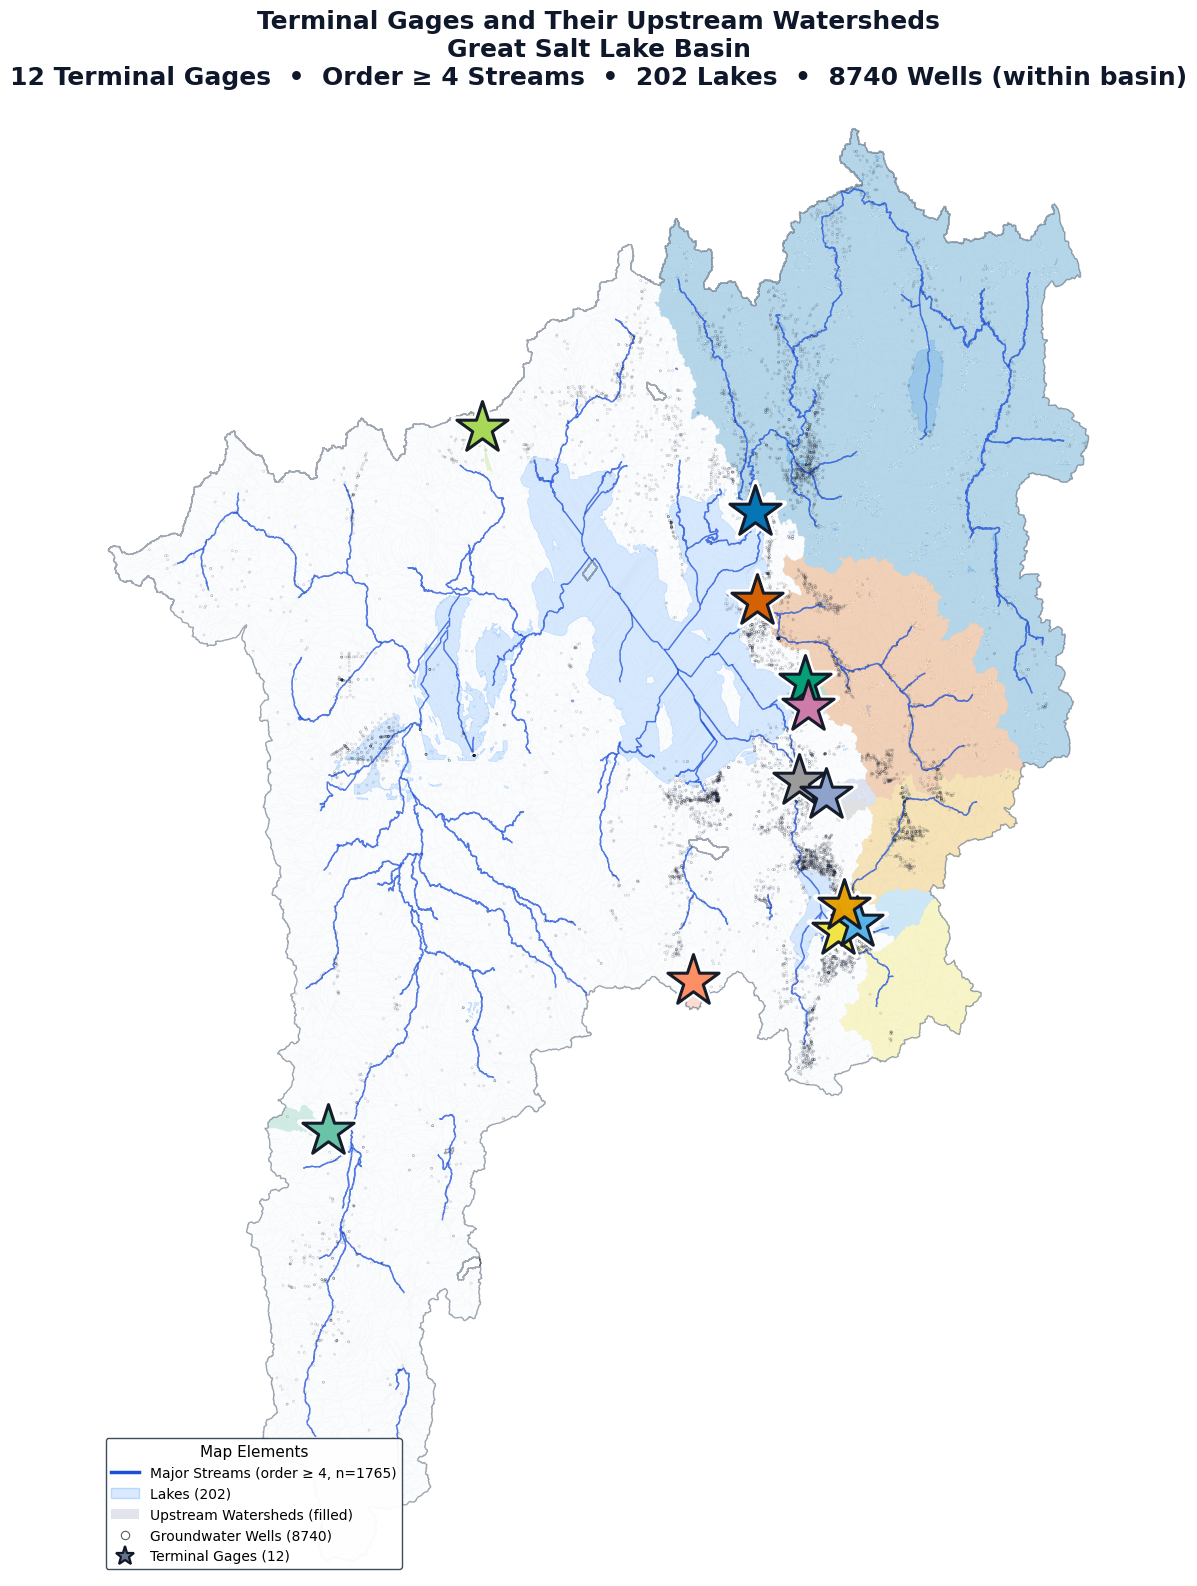

Saved: ../reports/figures/enhanced_terminal_gages_watersheds.png
Wells plotted: 8740 of 8752 (within basin)
Streams plotted: 1765 of 6717 (order >= 4)


In [20]:

def create_enhanced_watershed_visualization():
    """
    Enhanced watershed visualization (polished cartography):
    - Terminal gages only (stars), no other gages
    - Stream network filtered to order >= 4 (major rivers)
    - Wells clipped to basin and plotted (subtle, rasterized)
    - Softer, colorblind-safe palette + improved layer styling
    """
    import os
    import numpy as np
    import pandas as pd
    import geopandas as gpd
    import matplotlib as mpl
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch

    print("=== Creating Enhanced Watershed Visualization ===")

    # ----------------------------
    # Load data
    # ----------------------------
    terminal_mapping = pd.read_csv('../data/processed/terminal_gage_upstream_catchments.csv')
    subbasin_gdf = gpd.read_file('../data/raw/hydrography/gsl_catchment.shp')
    gage_df = pd.read_csv('../data/raw/hydrography/gsl_nwm_gage.csv')
    well_gdf = gpd.read_file('../data/raw/hydrography/well_shp.shp')
    stream_gdf = gpd.read_file('../data/raw/hydrography/gslb_stream.shp')
    lake_gdf = gpd.read_file('../data/raw/hydrography/lake.shp')

    # ----------------------------
    # Filter to major rivers only (order >= 4)
    # ----------------------------
    if 'strmOrder' not in stream_gdf.columns:
        raise ValueError(f"Expected 'strmOrder' in stream_gdf, found: {list(stream_gdf.columns)}")

    stream_gdf['strmOrder'] = pd.to_numeric(stream_gdf['strmOrder'], errors='coerce')
    major_streams = stream_gdf[stream_gdf['strmOrder'] >= 4].copy()
    print(f"  Streams total: {len(stream_gdf)}, order >= 4: {len(major_streams)}")

    # ----------------------------
    # Find linkno column
    # ----------------------------
    linkno_col = 'linkno' if 'linkno' in subbasin_gdf.columns else 'LINKNO'
    if linkno_col not in subbasin_gdf.columns:
        raise ValueError(f"Cannot find linkno column in subbasin_gdf. Columns: {list(subbasin_gdf.columns)}")

    # ----------------------------
    # Data preprocessing
    # ----------------------------
    if 'Gage_ID' in terminal_mapping.columns:
        terminal_mapping = terminal_mapping.rename(columns={
            'Gage_ID': 'gage_id',
            'Upstream_Catchment_ID': 'upstream_catchment_id'
        })

    terminal_mapping = terminal_mapping.dropna(subset=['upstream_catchment_id'])
    terminal_mapping['gage_id'] = terminal_mapping['gage_id'].astype(int)
    terminal_mapping['upstream_catchment_id'] = terminal_mapping['upstream_catchment_id'].astype(int)

    gage_df['id'] = gage_df['id'].astype(int)

    subbasin_gdf = subbasin_gdf.dropna(subset=[linkno_col])
    subbasin_gdf[linkno_col] = subbasin_gdf[linkno_col].astype(int)

    # Terminal gages and catchments dictionary
    terminal_gage_ids = terminal_mapping['gage_id'].unique().tolist()
    terminal_gages = gage_df[gage_df['id'].isin(terminal_gage_ids)].copy()

    terminal_gage_catchments = {}
    available_catchments = set(subbasin_gdf[linkno_col].unique())

    for gage_id in terminal_gage_ids:
        upstream_catchments = terminal_mapping.loc[
            terminal_mapping['gage_id'] == gage_id, 'upstream_catchment_id'
        ].tolist()
        valid = [c for c in upstream_catchments if c in available_catchments]
        if valid:
            terminal_gage_catchments[gage_id] = set(valid)

    # ----------------------------
    # Clip wells to basin boundary
    # ----------------------------
    # Single polygon covering the entire basin
    subbasin_union = subbasin_gdf.dissolve()

    # Match CRS for spatial join
    well_gdf_proj = well_gdf.to_crs(subbasin_gdf.crs)

    # Keep only wells inside basin polygon
    well_in_basin = gpd.sjoin(
        well_gdf_proj,
        subbasin_union[['geometry']],
        how='inner',
        predicate='within'
    ).drop(columns=['index_right'])
    print(f"  Wells total: {len(well_gdf)}, within basin: {len(well_in_basin)}")

    # ----------------------------
    # Convert to Web Mercator
    # ----------------------------
    subbasin_web = subbasin_gdf.to_crs('EPSG:3857')
    major_streams_web = major_streams.to_crs('EPSG:3857')
    lake_web = lake_gdf.to_crs('EPSG:3857')
    well_web = well_in_basin.to_crs('EPSG:3857')
    basin_outline_web = subbasin_union.to_crs('EPSG:3857')

    terminal_gages_web = gpd.GeoDataFrame(
        terminal_gages,
        geometry=gpd.points_from_xy(terminal_gages['longitude'], terminal_gages['latitude']),
        crs='EPSG:4326'
    ).to_crs('EPSG:3857')

    # ----------------------------
    # Color palette (colorblind-safe)
    # ----------------------------
    # Okabe–Ito + small extensions (first 12 used)
    safe_colors = [
        "#0072B2",  # blue
        "#D55E00",  # vermillion
        "#009E73",  # bluish green
        "#CC79A7",  # reddish purple
        "#F0E442",  # yellow
        "#56B4E9",  # sky blue
        "#E69F00",  # orange
        "#999999",  # gray
        "#8DA0CB",  # lavender
        "#FC8D62",  # salmon
        "#66C2A5",  # teal
        "#A6D854",  # light green
    ]
    terminal_gage_colors = dict(zip(terminal_gage_ids, safe_colors[:len(terminal_gage_ids)]))

    # ----------------------------
    # Matplotlib style
    # ----------------------------
    mpl.rcParams.update({
        "font.size": 11,
        "axes.titlesize": 18,
        "axes.titleweight": "bold",
        "legend.fontsize": 10,
        "legend.title_fontsize": 11
    })

    # ----------------------------
    # Create plot
    # ----------------------------
    fig, ax = plt.subplots(1, 1, figsize=(22, 16))

    # Basemap first (helps orientation)
    try:
        import contextily as ctx
        ctx.add_basemap(
            ax,
            crs=subbasin_web.crs,
            source=ctx.providers.CartoDB.Positron,
            zorder=0,
            alpha=0.45
        )
    except Exception:
        pass

    # Subbasin background (subtle texture)
    subbasin_web.plot(
        ax=ax,
        color="#F8FAFC",
        edgecolor="#E8EDF3",
        linewidth=0.08,
        alpha=0.55,
        zorder=1
    )

    # Lakes (soft)
    lake_web.plot(
        ax=ax,
        color="#93C5FD",
        edgecolor="#60A5FA",
        linewidth=0.4,
        alpha=0.35,
        zorder=2
    )

    # Upstream watersheds per terminal gage (soft fills)
    for gage_id in terminal_gage_ids:
        if gage_id not in terminal_gage_catchments:
            continue

        upstream_catchments = list(terminal_gage_catchments[gage_id])
        upstream_basins = subbasin_web[subbasin_web[linkno_col].isin(upstream_catchments)]

        if not upstream_basins.empty:
            upstream_basins.plot(
                ax=ax,
                color=terminal_gage_colors[gage_id],
                alpha=0.28,
                edgecolor="none",
                zorder=3
            )

    # Basin outline (visual anchor)
    basin_outline_web.boundary.plot(
        ax=ax,
        color="#475569",
        linewidth=1.0,
        alpha=0.5,
        zorder=3.2
    )

    # Major streams (order >= 4)
    major_streams_web.plot(
        ax=ax,
        color="#1D4ED8",
        linewidth=1.05,
        alpha=0.75,
        zorder=4
    )

    # Wells (subtle, rasterized for performance)
    well_web.plot(
        ax=ax,
        marker="o",
        markersize=2.2,
        facecolor="none",
        edgecolor="#0F172A",
        linewidth=0.35,
        alpha=0.25,
        zorder=5,
        rasterized=True
    )

    # Terminal gages as stars with halo
    for _, row in terminal_gages_web.iterrows():
        gage_id = int(row["id"])
        if gage_id not in terminal_gage_catchments:
            continue

        x, y = row.geometry.x, row.geometry.y
        c = terminal_gage_colors[gage_id]

        # White halo underlay
        ax.scatter(
            [x], [y],
            c="white",
            marker="*",
            s=1900,
            edgecolors="white",
            linewidths=4.0,
            zorder=6
        )

        # Colored star
        ax.scatter(
            [x], [y],
            c=c,
            marker="*",
            s=1500,
            edgecolors="#111827",
            linewidths=2.2,
            zorder=7,
            alpha=0.98
        )

    # ----------------------------
    # Legend
    # ----------------------------
    legend_elements = [
        Line2D([0], [0], color="#1D4ED8", lw=2.5,
               label=f"Major Streams (order ≥ 4, n={len(major_streams)})"),
        Patch(facecolor="#93C5FD", edgecolor="#60A5FA", alpha=0.35,
              label=f"Lakes ({len(lake_gdf)})"),
        Patch(facecolor="#94A3B8", edgecolor="none", alpha=0.28,
              label="Upstream Watersheds (filled)"),
        Line2D([0], [0], marker="o", color="none",
               markerfacecolor="none", markeredgecolor="#0F172A",
               markeredgewidth=0.8, markersize=6, alpha=0.7,
               label=f"Groundwater Wells ({len(well_in_basin)})"),
        Line2D([0], [0], marker="*", color="none",
               markerfacecolor="#64748B", markeredgecolor="#111827",
               markeredgewidth=1.6, markersize=14,
               label=f"Terminal Gages ({len(terminal_gage_ids)})"),
    ]

    ax.legend(
        handles=legend_elements,
        loc="lower left",
        frameon=True,
        fancybox=True,
        framealpha=0.95,
        facecolor="white",
        edgecolor="#334155",
        title="Map Elements"
    )

    # ----------------------------
    # Title / formatting / save
    # ----------------------------
    ax.set_title(
        "Terminal Gages and Their Upstream Watersheds\n"
        "Great Salt Lake Basin\n"
        f"{len(terminal_gage_ids)} Terminal Gages  •  "
        f"Order ≥ 4 Streams  •  "
        f"{len(lake_gdf)} Lakes  •  "
        f"{len(well_in_basin)} Wells (within basin)",
        pad=22,
        color="#0F172A"
    )

    ax.set_aspect('equal')
    ax.axis('off')
    ax.margins(0.01)
    plt.tight_layout()

    out_path = '../reports/figures/enhanced_terminal_gages_watersheds.png'
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(out_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.show()

    print(f"Saved: {out_path}")
    print(f"Wells plotted: {len(well_in_basin)} of {len(well_gdf)} (within basin)")
    print(f"Streams plotted: {len(major_streams)} of {len(stream_gdf)} (order >= 4)")


# Run
create_enhanced_watershed_visualization()



# find wells

In [14]:
# Perform spatial join between well_gdf and subbasin_gdf
# Use 'within' predicate to determine which catchment each well belongs to
wells_in_catchments = gpd.sjoin(
    well_gdf,
    subbasin_gdf[['linkno', 'geometry']],
    how='inner',
    predicate='within'
).rename(columns={'linkno': 'catchment_id'})

# Add gage information by matching catchment_id to upstream_catchment_id
wells_in_catchments = wells_in_catchments.merge(
    df_upstream[['Gage_ID', 'Gage_Name', 'Upstream_Catchment_ID']],
    left_on='catchment_id',
    right_on='Upstream_Catchment_ID',
    how='left'
)

# Convert column names to lowercase
wells_in_catchments.columns = wells_in_catchments.columns.str.lower()

# Drop unnecessary columns
wells_in_catchments = wells_in_catchments.drop(
    ['aquiferid', 'aquifer_na', 'state', 'index_right', 'upstream_catchment_id'], axis=1)

# Only keep rows where gage_id is not null
wells_in_catchments = wells_in_catchments.dropna(subset=['gage_id'])

# Save summary file
wells_in_catchments.to_csv("../data/processed/wells_with_catchment_info.csv", index=False)

# Group by catchment and count number of wells in each catchment
wells_count = wells_in_catchments.groupby(['catchment_id', 'gage_id', 'gage_name']).size().reset_index(
    name='well_count')
print("\nNumber of wells in each catchment:")
print(wells_count)

# Get detailed well information for each catchment
print("\nDetailed well information for each catchment:")
for catchment_id in wells_in_catchments['catchment_id'].unique():
    wells = wells_in_catchments[wells_in_catchments['catchment_id'] == catchment_id]
    gage_info = wells[['gage_id', 'gage_name']].iloc[0]
    print(
        f"\nWells in Catchment {catchment_id} (Gage {gage_info['gage_id']} - {gage_info['gage_name']}, {len(wells)} wells):")
    print(wells)



Number of wells in each catchment:
     catchment_id     gage_id                            gage_name  well_count
0     710119132.0  10126000.0         BEAR RIVER NEAR CORINNE - UT           1
1     710129059.0  10126000.0         BEAR RIVER NEAR CORINNE - UT           2
2     710148899.0  10126000.0         BEAR RIVER NEAR CORINNE - UT           3
3     710154841.0  10126000.0         BEAR RIVER NEAR CORINNE - UT           8
4     710160811.0  10126000.0         BEAR RIVER NEAR CORINNE - UT           2
..            ...         ...                                  ...         ...
589   710972343.0  10141000.0     WEBER RIVER NEAR PLAIN CITY - UT           1
590   710988246.0  10152000.0  SPANISH FORK NEAR LAKE SHORE - UTAH          20
591   711004110.0  10163000.0            PROVO RIVER AT PROVO - UT          25
592   711023947.0  10163000.0            PROVO RIVER AT PROVO - UT          11
593   711025943.0  10152000.0  SPANISH FORK NEAR LAKE SHORE - UTAH          53

[594 rows x 4 c

In [15]:
# Group wells by gage and count
gage_well_counts = wells_in_catchments.groupby(['gage_id', 'gage_name']).size().reset_index(name='well_count')

# Sort by well count descending
gage_well_counts = gage_well_counts.sort_values('well_count', ascending=False)

print("Wells per gage:")
print(gage_well_counts)


Wells per gage:
      gage_id                                         gage_name  well_count
0  10126000.0                      BEAR RIVER NEAR CORINNE - UT        1461
1  10141000.0                  WEBER RIVER NEAR PLAIN CITY - UT         732
6  10163000.0                         PROVO RIVER AT PROVO - UT         471
4  10152000.0               SPANISH FORK NEAR LAKE SHORE - UTAH          92
7  10168000.0     LITTLE COTTONWOOD CREEK @ JORDAN RIVER NR SLC          73
3  10143500.0  CENTERVILLE CREEK ABV. DIV NEAR CENTERVILLE - UT          20
5  10153100.0   HOBBLE CREEK AT 1650 WEST AT SPRINGVILLE - UTAH          16
2  10142000.0        FARMINGTON CR ABV DIV NR FARMINGTON - UTAH          13
8  10172860.0                        WARM CREEK NEAR GANDY - UT           1
9  10172952.0                  DUNN CREEK NEAR PARK VALLEY - UT           1


# plot each gage and upstream catchments

In [18]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')


def create_enhanced_gage_maps():
    """Create enhanced maps with insets for each terminal gage"""

    print("=== Creating Enhanced Terminal Gage Maps ===")

    # Load data
    try:
        subbasin_gdf = gpd.read_file('../data/raw/hydrography/gsl_catchment.shp')
        stream_gdf = gpd.read_file('../data/raw/hydrography/gslb_stream.shp')
        lake_gdf = gpd.read_file('../data/raw/hydrography/lake.shp')
        well_gdf = gpd.read_file('../data/raw/hydrography/well_shp.shp')
        gage_df = pd.read_csv('../data/raw/hydrography/gsl_nwm_gage.csv')

        try:
            terminal_relationships = pd.read_csv('../data/processed/terminal_gage_upstream_catchments.csv')
        except:
            terminal_relationships = pd.read_csv('../data/processed/terminal_gage_upstream_catchments.csv')

        print("✅ Data loaded successfully")

    except Exception as e:
        print(f"❌ Error loading data: {e}")
        return

    # Data preprocessing
    linkno_col = 'linkno' if 'linkno' in subbasin_gdf.columns else 'LINKNO'

    if 'Gage_ID' in terminal_relationships.columns:
        terminal_relationships = terminal_relationships.rename(columns={
            'Gage_ID': 'gage_id',
            'Upstream_Catchment_ID': 'upstream_catchment_id'
        })

    gage_gdf = gpd.GeoDataFrame(
        gage_df,
        geometry=gpd.points_from_xy(gage_df['longitude'], gage_df['latitude']),
        crs='EPSG:4326'
    )

    terminal_gage_ids = terminal_relationships['gage_id'].unique()
    print(f"🎯 Will create maps for {len(terminal_gage_ids)} terminal gages")

    output_dir = '../reports/figures/enhanced_gage_maps'
    os.makedirs(output_dir, exist_ok=True)

    # Create map for each terminal gage
    for terminal_gage_id in tqdm(terminal_gage_ids, desc="Creating maps"):
        try:
            create_single_map(
                terminal_gage_id, terminal_relationships, subbasin_gdf,
                stream_gdf, lake_gdf, well_gdf, gage_gdf, gage_df,
                linkno_col, output_dir
            )
        except Exception as e:
            print(f"❌ Failed to create map for Gage {terminal_gage_id}: {e}")

    print(f"✅ All maps saved to: {output_dir}")


def create_single_map(terminal_gage_id, terminal_relationships, subbasin_gdf,
                      stream_gdf, lake_gdf, well_gdf, gage_gdf, gage_df,
                      linkno_col, output_dir):
    """Create map for a single gage"""

    # Harmonious color scheme
    colors = {
        'terminal_gage': '#FFFF00',  # Bright yellow star
        'terminal_catchment': '#CD5C5C',  # Indian red
        'upstream_catchments': '#D2B48C',  # Tan
        'other_gages': '#FF8C42',  # Orange
        'wells': '#654321',  # Dark brown
        'streams': '#4682B4',  # Steel blue
        'lakes': '#87CEEB',  # Sky blue
        'inset_all': '#F5DEB3',  # Wheat
        'inset_highlight': '#CD853F',  # Peru
    }

    # Get gage info
    terminal_gage_info = gage_df[gage_df['id'] == terminal_gage_id]
    if terminal_gage_info.empty:
        return

    gage_name = terminal_gage_info.iloc[0].get('name', f'Gage {terminal_gage_id}')

    # Get upstream catchments
    upstream_catchments = terminal_relationships[
        terminal_relationships['gage_id'] == terminal_gage_id
        ]['upstream_catchment_id'].tolist()

    if not upstream_catchments:
        return

    upstream_basins = subbasin_gdf[subbasin_gdf[linkno_col].isin(upstream_catchments)]
    if upstream_basins.empty:
        return

    terminal_gage_point = gage_gdf[gage_gdf['id'] == terminal_gage_id]
    if terminal_gage_point.empty:
        return

    # Find terminal catchment
    terminal_catchment_id = None
    terminal_point = terminal_gage_point.geometry.iloc[0]

    for _, basin in upstream_basins.iterrows():
        if basin.geometry.contains(terminal_point):
            terminal_catchment_id = basin[linkno_col]
            break

    # Separate basins
    if terminal_catchment_id is not None:
        terminal_basin = upstream_basins[upstream_basins[linkno_col] == terminal_catchment_id]
        other_upstream_basins = upstream_basins[upstream_basins[linkno_col] != terminal_catchment_id]
    else:
        terminal_basin = gpd.GeoDataFrame()
        other_upstream_basins = upstream_basins

    # Filter features within watershed only
    upstream_union = upstream_basins.unary_union

    # Use within instead of intersects to ensure features are fully contained
    local_streams = stream_gdf[
        stream_gdf.geometry.apply(lambda x: upstream_union.contains(x) or upstream_union.intersects(x))]
    local_lakes = lake_gdf[lake_gdf.geometry.apply(lambda x: upstream_union.contains(x))]
    local_wells = well_gdf[well_gdf.geometry.apply(lambda x: upstream_union.contains(x))]
    local_gages = gage_gdf[gage_gdf.geometry.apply(lambda x: upstream_union.contains(x))]
    local_gages = local_gages[local_gages['id'] != terminal_gage_id]

    # Create figure
    fig, ax_main = plt.subplots(1, 1, figsize=(14, 11))
    ax_main.set_facecolor('#FAFAFA')

    # Draw main map
    plot_main_map(ax_main, colors, other_upstream_basins, terminal_basin,
                  local_lakes, local_streams, local_wells, local_gages,
                  terminal_gage_point, upstream_basins)

    # Create inset map in top right corner
    ax_inset = fig.add_axes([0.72, 0.72, 0.26, 0.26])
    plot_inset_map(ax_inset, colors, subbasin_gdf, stream_gdf, lake_gdf,
                   upstream_basins, terminal_gage_point)

    # Add legend and title
    add_legend_and_title(fig, ax_main, colors, terminal_gage_id, gage_name,
                         len(local_gages), len(local_wells), len(local_lakes))

    # Save figure
    safe_name = gage_name.replace('/', '_').replace('\\', '_')[:50]
    filename = f"gage_{terminal_gage_id}_{safe_name}.png"
    filepath = os.path.join(output_dir, filename)

    plt.savefig(filepath, dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.close()


def plot_main_map(ax, colors, other_upstream_basins, terminal_basin,
                  local_lakes, local_streams, local_wells, local_gages,
                  terminal_gage_point, upstream_basins):
    """Draw main map"""

    # Upstream basins
    if not other_upstream_basins.empty:
        other_upstream_basins.plot(ax=ax, color=colors['upstream_catchments'],
                                   alpha=0.7, edgecolor=colors['terminal_catchment'],
                                   linewidth=1.0)

    # Terminal basin - Indian red
    if not terminal_basin.empty:
        terminal_basin.plot(ax=ax, color=colors['terminal_catchment'],
                            alpha=0.6, edgecolor='#8B0000', linewidth=2.5)

    # Lakes (only those fully within watershed)
    if not local_lakes.empty:
        local_lakes.plot(ax=ax, color=colors['lakes'], alpha=0.8,
                         edgecolor=colors['streams'], linewidth=1)

    # Streams
    if not local_streams.empty:
        local_streams.plot(ax=ax, color=colors['streams'],
                           linewidth=2.0, alpha=0.9, zorder=3)

    # Wells
    if not local_wells.empty:
        local_wells.plot(ax=ax, color=colors['wells'], markersize=50,
                         alpha=0.8, marker='s', edgecolor='#654321',
                         linewidth=1, zorder=4)

    # Other gages - above streams
    if not local_gages.empty:
        local_gages.plot(ax=ax, color=colors['other_gages'], markersize=120,
                         alpha=0.9, edgecolor='#FF4500', linewidth=2, zorder=5)

    # Terminal gage - bright yellow large star with black outline
    terminal_gage_point.plot(ax=ax, color=colors['terminal_gage'],
                             marker='*', markersize=600,
                             edgecolor='#000000', linewidth=4,
                             alpha=1.0, zorder=10)

    # Set bounds
    bounds = upstream_basins.total_bounds
    buffer = max(bounds[2] - bounds[0], bounds[3] - bounds[1]) * 0.05
    ax.set_xlim(bounds[0] - buffer, bounds[2] + buffer)
    ax.set_ylim(bounds[1] - buffer, bounds[3] + buffer)
    ax.set_aspect('equal')
    ax.axis('off')


def plot_inset_map(ax, colors, subbasin_gdf, stream_gdf, lake_gdf,
                   upstream_basins, terminal_gage_point):
    """Draw inset map with frame"""

    # All basins
    subbasin_gdf.plot(ax=ax, color=colors['inset_all'], alpha=0.6,
                      edgecolor='#DEB887', linewidth=0.5)

    # Streams
    stream_gdf.plot(ax=ax, color='#4169E1', linewidth=0.8, alpha=0.7)

    # Lakes
    lake_gdf.plot(ax=ax, color='#B0E0E6', alpha=0.7,
                  edgecolor='#4169E1', linewidth=0.5)

    # Highlight current basin
    upstream_basins.plot(ax=ax, color=colors['inset_highlight'],
                         alpha=0.9, edgecolor='#8B4513', linewidth=1.5)

    # Terminal gage - bright yellow with black outline
    terminal_gage_point.plot(ax=ax, color=colors['terminal_gage'],
                             marker='*', markersize=150,
                             edgecolor='#000000', linewidth=2, zorder=5)

    # Set bounds and style
    basin_bounds = subbasin_gdf.total_bounds
    ax.set_xlim(basin_bounds[0], basin_bounds[2])
    ax.set_ylim(basin_bounds[1], basin_bounds[3])
    ax.set_aspect('equal')
    ax.axis('off')

    ax.set_title('Location Overview',
                 fontsize=10, fontweight='bold', pad=5, color='#2F4F4F')

    # Add prominent frame
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(3)
        spine.set_edgecolor('#000000')  # Black frame

    # Add background color
    ax.patch.set_facecolor('#FFFFFF')
    ax.patch.set_alpha(0.9)


def add_legend_and_title(fig, ax, colors, terminal_gage_id, gage_name,
                         num_gages, num_wells, num_lakes):
    """Add legend and title"""

    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch

    legend_elements = [
        Line2D([0], [0], marker='*', color='w',
               markerfacecolor=colors['terminal_gage'], markersize=18,
               markeredgecolor='#000000', markeredgewidth=2,
               label=f'Terminal Gage {terminal_gage_id}'),

        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=colors['other_gages'], markersize=12,
               markeredgecolor='#FF4500', markeredgewidth=1.5,
               label=f'Other Gages ({num_gages})'),

        Line2D([0], [0], marker='s', color='w',
               markerfacecolor=colors['wells'], markersize=10,
               markeredgecolor='#654321', markeredgewidth=1,
               label=f'Wells ({num_wells})'),

        Line2D([0], [0], color=colors['streams'], linewidth=3,
               label='Stream Network'),

        Patch(color=colors['lakes'], alpha=0.8,
              label=f'Lakes ({num_lakes})'),

        Patch(color=colors['terminal_catchment'], alpha=0.6,
              label='Terminal Catchment'),

        Patch(color=colors['upstream_catchments'], alpha=0.7,
              label='Upstream Catchments'),
    ]

    # Create legend
    legend = ax.legend(handles=legend_elements,
                       loc='upper left', bbox_to_anchor=(0.02, 0.98),
                       fontsize=11, frameon=True, fancybox=True,
                       shadow=True, framealpha=0.95, facecolor='white',
                       edgecolor='#2F4F4F', title='Map Elements',
                       title_fontsize=12)

    # Set title
    title_text = f"Terminal Gage {terminal_gage_id}\n{gage_name}\nUpstream Watershed Analysis"
    ax.set_title(title_text, fontsize=16, fontweight='bold',
                 pad=20, color='#2F4F4F', ha='center')

    # Add stats text box
    stats_text = f"Gages: {num_gages} | Wells: {num_wells} | Lakes: {num_lakes}"
    ax.text(0.02, 0.02, stats_text, transform=ax.transAxes,
            fontsize=10, bbox=dict(boxstyle="round,pad=0.3",
                                   facecolor='white', alpha=0.8,
                                   edgecolor='#2F4F4F'),
            verticalalignment='bottom', color='#2F4F4F')


def create_visualization(result_df):
    """Create visualization of upstream gage relationships"""

    print("🎨 Creating upstream gage relationship visualization...")

    try:
        import matplotlib.pyplot as plt
        import seaborn as sns

        # Set style
        plt.style.use('default')
        sns.set_palette("husl")

        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

        # 1. Number of upstream gages per terminal gage
        terminal_counts = result_df.groupby('terminal_gage_id').size().sort_values(ascending=False)
        ax1.bar(range(len(terminal_counts)), terminal_counts.values,
                color='steelblue', alpha=0.7)
        ax1.set_xlabel('Terminal Gage Index')
        ax1.set_ylabel('Number of Upstream Gages')
        ax1.set_title('Upstream Gages per Terminal Gage')
        ax1.grid(True, alpha=0.3)

        # 2. Distance distribution histogram
        if result_df['distance_km'].notna().sum() > 0:
            distances = result_df['distance_km'].dropna()
            ax2.hist(distances, bins=20, color='lightcoral', alpha=0.7, edgecolor='black')
            ax2.set_xlabel('Distance (km)')
            ax2.set_ylabel('Frequency')
            ax2.set_title('Distribution of Distances')
            ax2.grid(True, alpha=0.3)

        # 3. Average distance for each terminal gage
        avg_distances = result_df.groupby('terminal_gage_id')['distance_km'].mean().sort_values()
        ax3.bar(range(len(avg_distances)), avg_distances.values,
                color='lightgreen', alpha=0.7)
        ax3.set_xlabel('Terminal Gage Index')
        ax3.set_ylabel('Average Distance (km)')
        ax3.set_title('Average Distance to Upstream Gages')
        ax3.grid(True, alpha=0.3)

        # 4. Distance vs count scatter plot
        terminal_stats = result_df.groupby('terminal_gage_id').agg({
            'non_terminal_gage_id': 'count',
            'distance_km': 'mean'
        }).reset_index()

        ax4.scatter(terminal_stats['distance_km'], terminal_stats['non_terminal_gage_id'],
                    alpha=0.7, s=100, color='purple')
        ax4.set_xlabel('Average Distance (km)')
        ax4.set_ylabel('Number of Upstream Gages')
        ax4.set_title('Distance vs Count Relationship')
        ax4.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig("../reports/figures/upstream_gages_analysis.png", dpi=300, bbox_inches='tight')
        plt.show()

        print("✅ Visualization saved to: ../reports/figures/upstream_gages_analysis.png")

    except Exception as e:
        print(f"⚠️ Failed to create visualization: {e}")


# Run main function to create maps
if __name__ == "__main__":
    try:
        create_enhanced_gage_maps()
        print("🎉 All maps created successfully!")
    except Exception as e:
        print(f"❌ Error during map creation: {e}")
        import traceback

        traceback.print_exc()


=== Creating Enhanced Terminal Gage Maps ===
✅ Data loaded successfully
🎯 Will create maps for 12 terminal gages


Creating maps:   0%|          | 0/12 [00:30<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def create_upstream_catchment_schematic():
    """
    Create a schematic diagram showing upstream catchment concept using watershed shapes
    """
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    
    # Colors
    colors = {
        'terminal': '#FF6B6B',     # Red for terminal catchment
        'upstream': '#4ECDC4',     # Teal for upstream catchments
        'stream': '#45B7D1',       # Blue for streams
        'gage': '#FFA07A',         # Orange for gages
        'well': '#8B4513',         # Brown for wells
        'boundary': '#2C3E50'      # Dark for boundaries
    }
    
    # Draw watershed boundaries as irregular polygons
    # Terminal catchment (bottom center)
    terminal_catchment = patches.Polygon(
        [(7, 1), (10, 1.5), (11, 3), (10, 4), (8, 4.5), (6, 3.5), (5.5, 2)], 
        closed=True, facecolor=colors['terminal'], 
        edgecolor=colors['boundary'], linewidth=3, alpha=0.8)
    ax.add_patch(terminal_catchment)
    
    # Upstream catchments
    upstream_catchments = [
        # Left upstream catchment
        patches.Polygon([(1, 4), (3.5, 3.5), (4.5, 5), (3, 6.5), (1, 6), (0, 5)], 
                       closed=True, facecolor=colors['upstream'], 
                       edgecolor=colors['boundary'], linewidth=2, alpha=0.7),
        
        # Top left upstream catchment
        patches.Polygon([(2, 7), (4, 6.5), (5, 8), (4, 9.5), (2, 9), (1, 8)], 
                       closed=True, facecolor=colors['upstream'], 
                       edgecolor=colors['boundary'], linewidth=2, alpha=0.7),
        
        # Top middle upstream catchment  
        patches.Polygon([(5, 8.5), (7, 8), (8.5, 9.5), (7, 10.5), (5, 10), (4, 9)], 
                       closed=True, facecolor=colors['upstream'], 
                       edgecolor=colors['boundary'], linewidth=2, alpha=0.7),
        
        # Right upstream catchment
        patches.Polygon([(8.5, 5), (11, 4.5), (12, 6), (11, 7.5), (9, 7), (8, 6)], 
                       closed=True, facecolor=colors['upstream'], 
                       edgecolor=colors['boundary'], linewidth=2, alpha=0.7),
        
        # Top right upstream catchment
        patches.Polygon([(10, 8), (12.5, 7.5), (13, 9), (12, 10), (10, 9.5), (9, 8.5)], 
                       closed=True, facecolor=colors['upstream'], 
                       edgecolor=colors['boundary'], linewidth=2, alpha=0.7),
    ]
    
    for catchment in upstream_catchments:
        ax.add_patch(catchment)
    
    # Draw stream network connecting all catchments
    stream_segments = [
        # Main stem
        [(2.5, 5.5), (4, 4.5), (6, 3.5), (8.5, 2.8)],
        # Left tributary
        [(2.5, 8), (3, 7), (3.5, 6)],
        # Top tributary  
        [(6, 9), (6.5, 8.5), (5.5, 7), (5, 5.5)],
        # Right tributary
        [(10, 6.5), (9.5, 5.5), (8.5, 4.5)],
        # Far right tributary
        [(11.5, 8.5), (10.5, 7.5), (10, 6.5)],
    ]
    
    for segment in stream_segments:
        x_coords = [point[0] for point in segment]
        y_coords = [point[1] for point in segment]
        ax.plot(x_coords, y_coords, color=colors['stream'], linewidth=4, alpha=0.9, zorder=3)
        
        # Add flow direction arrows
        for i in range(len(segment)-1):
            start = segment[i]
            end = segment[i+1]
            mid_x = (start[0] + end[0]) / 2
            mid_y = (start[1] + end[1]) / 2
            dx = end[0] - start[0]
            dy = end[1] - start[1]
            ax.annotate('', xy=(mid_x + dx*0.1, mid_y + dy*0.1), 
                       xytext=(mid_x - dx*0.1, mid_y - dy*0.1),
                       arrowprops=dict(arrowstyle='->', color=colors['stream'], lw=2))
    
    # Add gages at key locations
    gage_locations = [
        (8.5, 2.8, 'Terminal Gage'),   # Terminal gage
        (4, 4.5, 'Gage A'),           # Upstream gage
        (6, 9, 'Gage B'),             # Upstream gage  
        (10, 6.5, 'Gage C'),          # Upstream gage
        (2.5, 8, 'Gage D'),           # Upstream gage
    ]
    
    for x, y, label in gage_locations:
        if 'Terminal' in label:
            ax.scatter(x, y, s=400, c=colors['gage'], marker='*', 
                      edgecolor='black', linewidth=2, zorder=5)
            ax.text(x+0.5, y, label, fontsize=11, fontweight='bold', 
                   ha='left', va='center')
        else:
            ax.scatter(x, y, s=200, c=colors['gage'], marker='o', 
                      edgecolor='black', linewidth=1.5, zorder=5)
            ax.text(x+0.3, y+0.3, label, fontsize=9, ha='left', va='bottom')
    
    # Add wells scattered throughout upstream catchments
    well_positions = [
        (2, 5), (3, 4.5), (1.5, 6), (3, 8), (2.5, 9), (6, 9.5), (7, 8.5),
        (9.5, 6), (11, 6.5), (10.5, 8.5), (11.5, 9), (9, 5.5), (10.5, 5.5)
    ]
    
    for x, y in well_positions:
        ax.scatter(x, y, s=80, c=colors['well'], marker='s', 
                  edgecolor='black', linewidth=1, alpha=0.8, zorder=4)
    
    # Add catchment labels
    catchment_labels = [
        (8.5, 2.5, 'Terminal\nCatchment', colors['terminal']),
        (2.5, 5, 'Upstream\nCatchment 1', colors['upstream']),
        (3, 8, 'Upstream\nCatchment 2', colors['upstream']),
        (6.5, 9, 'Upstream\nCatchment 3', colors['upstream']),
        (10, 6, 'Upstream\nCatchment 4', colors['upstream']),
        (11.5, 8.5, 'Upstream\nCatchment 5', colors['upstream']),
    ]
    
    for x, y, label, color in catchment_labels:
        ax.text(x, y, label, fontsize=10, ha='center', va='center', fontweight='bold',
               bbox=dict(boxstyle="round,pad=0.3", facecolor='white', 
                        edgecolor=color, linewidth=2, alpha=0.9))
    
    # Add concept explanation
    concept_text = """
    UPSTREAM CATCHMENT CONCEPT:
    
    • Terminal Gage: Point where we measure flow
    • Terminal Catchment: Area directly draining to terminal gage
    • Upstream Catchments: All areas that contribute flow 
      to the terminal gage through the stream network
    • Wells: Groundwater monitoring points within catchments
    • Stream Flow Direction: Water flows from upstream 
      catchments → terminal catchment → terminal gage
    """
    
    ax.text(0.5, 1, concept_text, fontsize=11, 
           bbox=dict(boxstyle="round,pad=0.5", facecolor='lightblue', 
                    edgecolor='navy', alpha=0.9),
           verticalalignment='bottom', transform=ax.transAxes)
    
    # Add title
    ax.set_title('Upstream Catchment Identification\nWatershed Connectivity Concept', 
                fontsize=16, fontweight='bold', pad=20)
    
    # Create legend
    legend_elements = [
        patches.Patch(color=colors['terminal'], label='Terminal Catchment'),
        patches.Patch(color=colors['upstream'], label='Upstream Catchments'),
        plt.Line2D([0], [0], color=colors['stream'], linewidth=3, label='Stream Network'),
        plt.Line2D([0], [0], marker='*', color='w', markerfacecolor=colors['gage'], 
                  markersize=15, label='Terminal Gage', markeredgecolor='black'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['gage'], 
                  markersize=10, label='Upstream Gages', markeredgecolor='black'),
        plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=colors['well'], 
                  markersize=8, label='Wells', markeredgecolor='black')
    ]
    
    ax.legend(handles=legend_elements, loc='upper right', 
             fontsize=11, frameon=True, fancybox=True, shadow=True)
    
    # Set limits and styling
    ax.set_xlim(-1, 14)
    ax.set_ylim(0, 11)
    ax.set_aspect('equal')
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Upstream catchment schematic displayed")

# Create the schematic
create_upstream_catchment_schematic()